# **PENJELASAN HASIL GRAFIK**

Analisis Keyword / Hashtag – Raecca vs Competitor

Notebook ini menganalisis efektivitas hashtag berdasarkan 3 metrik utama:
- Average Total Clicks Ads
- Average Views
- Average CTR

Analisis dilakukan per brand, sehingga adil untuk perbandingan.

# **Top 15 Hashtag | Rata-Rata Total Clicks Ads**

Penjelasan:
- Grafik ini menunjukkan 15 hashtag dengan rata-rata jumlah klik iklan tertinggi untuk brand ini.
- Semakin tinggi nilai Average Total Clicks Ads, semakin besar kemampuan hashtag tersebut dalam mendorong audiens melakukan klik setelah melihat video.
- Hashtag yang berada di posisi teratas dapat dikategorikan sebagai high-performing traffic driver, karena tidak hanya menarik perhatian, tetapi juga memicu tindakan lanjutan dari audiens.

📌 **Implikasi bisnis:**

- Hashtag ini cocok digunakan untuk campaign performance / conversion
- Layak diprioritaskan untuk scaling ads
- Menunjukkan keyword dengan niat beli yang relatif tinggi

---

# **Top 15 Hashtag | Rata-Rata Views**

Penjelasan : 
- Grafik ini menampilkan hashtag dengan rata-rata jumlah views tertinggi, yang mencerminkan daya jangkau dan exposure konten.
- Hashtag dengan views tinggi menunjukkan bahwa keyword tersebut :
  - Mudah didorong oleh algoritma
  - Relevan dengan minat audiens yang lebih luas

Namun, tingginya views tidak selalu berbanding lurus dengan performa iklan atau konversi.

Implikasi bisnis :
- Cocok untuk awareness campaign
- Digunakan pada konten edukasi, branding, atau soft selling
- Perlu dikombinasikan dengan CTA dan keyword konversi agar efektif untuk ads

---

# **Top 15 Hashtag | Rata-Rata CTR**
Penjelasan :
Grafik ini memperlihatkan hashtag dengan rata-rata Click Through Rate (CTR) tertinggi, yang mencerminkan kualitas audiens dan relevansi konten.

CTR yang tinggi menunjukkan bahwa:
- Audiens yang melihat konten lebih tertarik untuk klik
- Hashtag tersebut memiliki kecocokan yang baik dengan pesan dan penawaran produk
- Hashtag dengan CTR tinggi meskipun views tidak besar biasanya bersifat niche namun berkualitas.

Implikasi bisnis :
- Sangat cocok untuk performance ads
- Efektif untuk produk baru atau promo
- Dapat digunakan sebagai keyword utama untuk optimasi konversi

# **LOAD DATA**

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

from matplotlib import cm
from matplotlib.colors import Normalize

file_path = r"G:\5. PT Raecca Kreasi Indonesia\7. Data Kompetitor\Data Video Raecca dan Competitor.xlsx"

df = pd.read_excel(file_path, sheet_name='All Data')

print(df.head())

                                             Caption Durasi       Creator  \
0  Sukaaaa😍 #capcut #lipstikviral #ombrelips #tim...    11s      elle_gum   
1                               #lipsticktimephoria     11s        mz1653   
2  Cakep bgtt di bibir🫦 #timephoriablurringtint #...    12s      cykiaaa_   
3              #implora #liptint #liptintviral #fyp     12s   sesukanoobz   
4        lipstik implora#lipstikmurah #lipstikviral     12s  aidamaulana5   

          Publish Data    Revenue  Produk Terjual  Viewes         GPM  \
0  2026/01/30 22:19:19  286351.56               2      90  3181683.97   
1  2025/12/15 13:47:45  220322.32               2     928   237416.29   
2  2026/02/01 18:55:25  330424.35               3     422   782996.10   
3  2026/01/10 21:13:55   70314.89               1     115   611433.81   
4  2026/02/01 15:41:08   52264.64               1      48  1088846.76   

       CPA     CTR  Ads Spend  Ads ROAS              Brand Tanggal Upload  \
0  5727.03  0.5667   

# **DATA CLEANING (METRIK YANG DIPAKAI)**

In [2]:
df['Viewes'] = pd.to_numeric(df['Viewes'], errors='coerce')
df['CTR'] = pd.to_numeric(df['CTR'], errors='coerce')
df['Total Clicks Ads'] = pd.to_numeric(df['Total Clicks Ads'], errors='coerce')

df = df.dropna(subset=['Caption', 'Brand'])

# **EKSTRAK HASHTAG**

In [3]:
def extract_hashtags(text):
    return re.findall(r"#(\w+)", text.lower())

df['hashtag'] = df['Caption'].apply(extract_hashtags)

# **EXPLODE HASHTAG**

In [4]:
df = df.explode('hashtag')
df = df.dropna(subset=['hashtag'])

# **AGREGASI HASHTAG PER BRAND**

In [5]:
agg_df = (
    df
    .groupby(['Brand', 'hashtag'])
    .agg(
        avg_clicks_ads=('Total Clicks Ads', 'mean'),
        avg_views=('Viewes', 'mean'),
        avg_ctr=('CTR', 'mean'),
        total_video=('hashtag', 'count')
    )
    .reset_index()
)

# filter hashtag yang terlalu jarang
agg_df = agg_df[agg_df['total_video'] >= 2]

In [6]:
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 10

# **VISUALISASI: 3 GRAFIK PER BRAND**

C:\Users\febyrenaldi\AppData\Roaming\Python\Python311-arm64\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


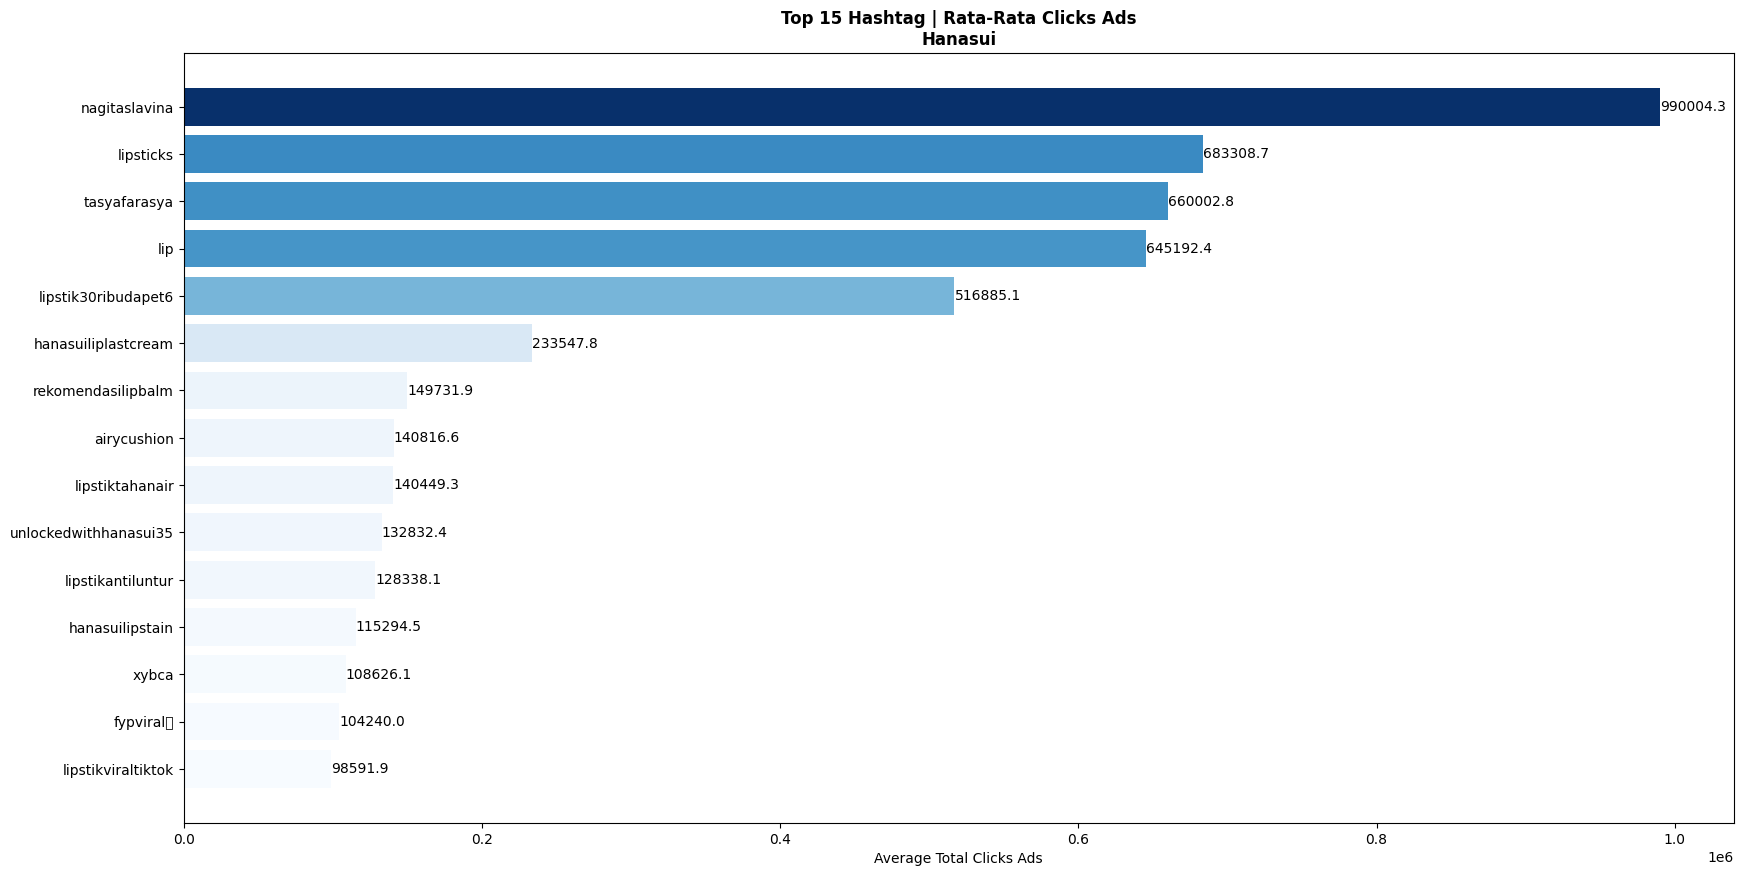

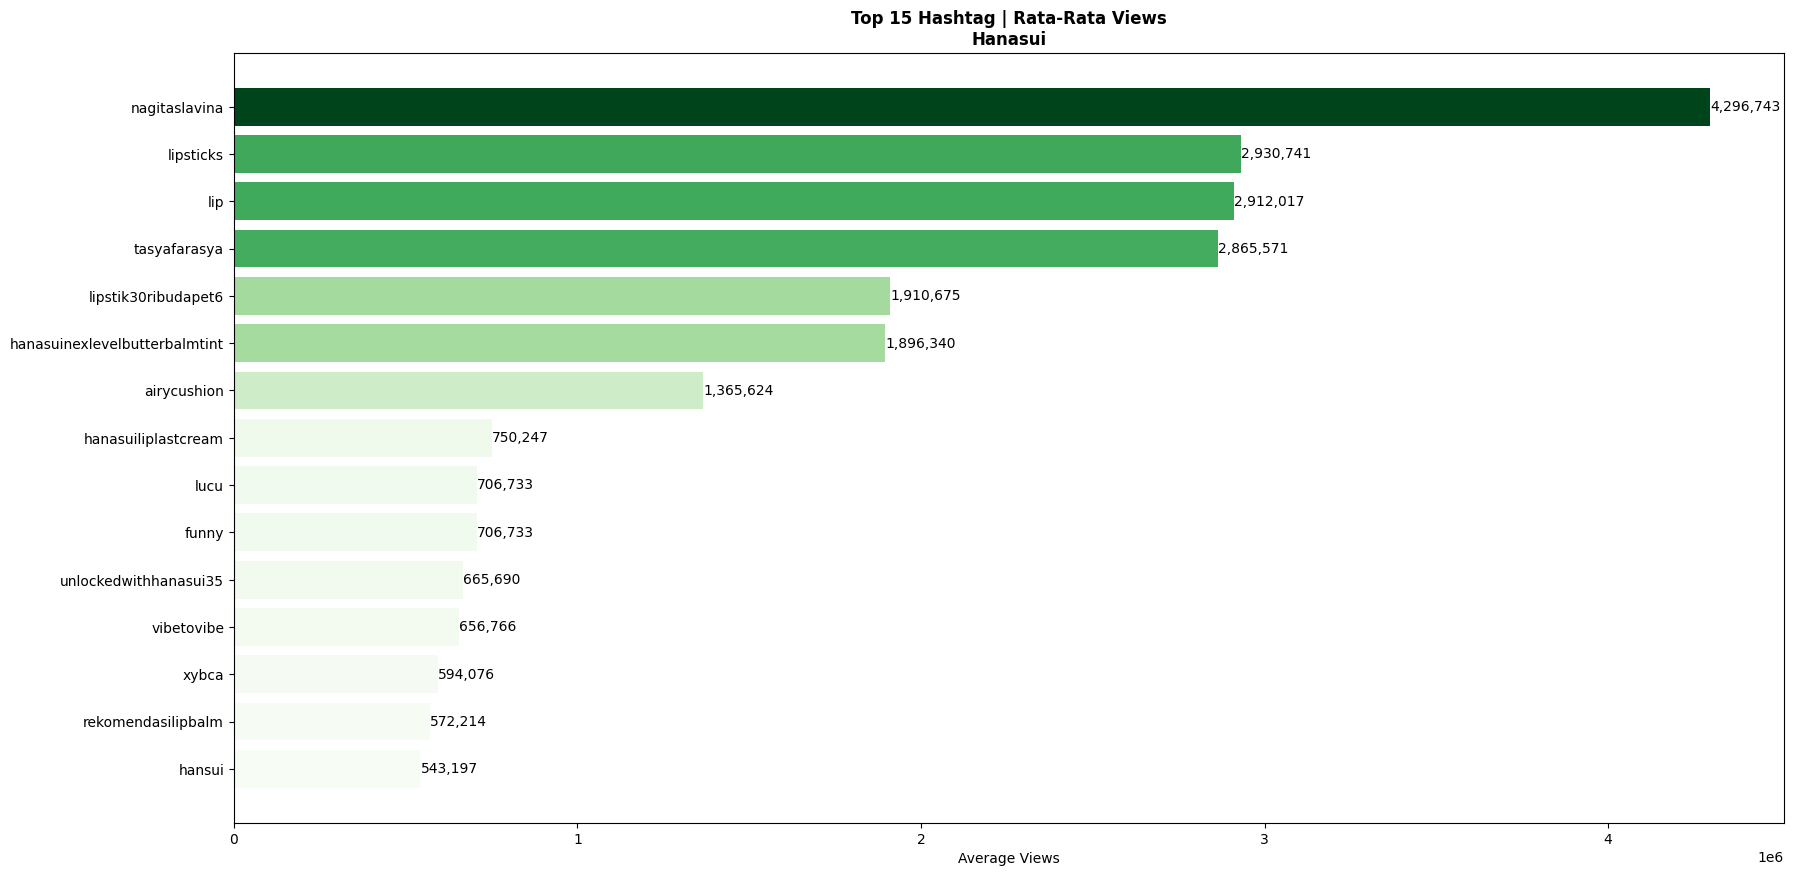

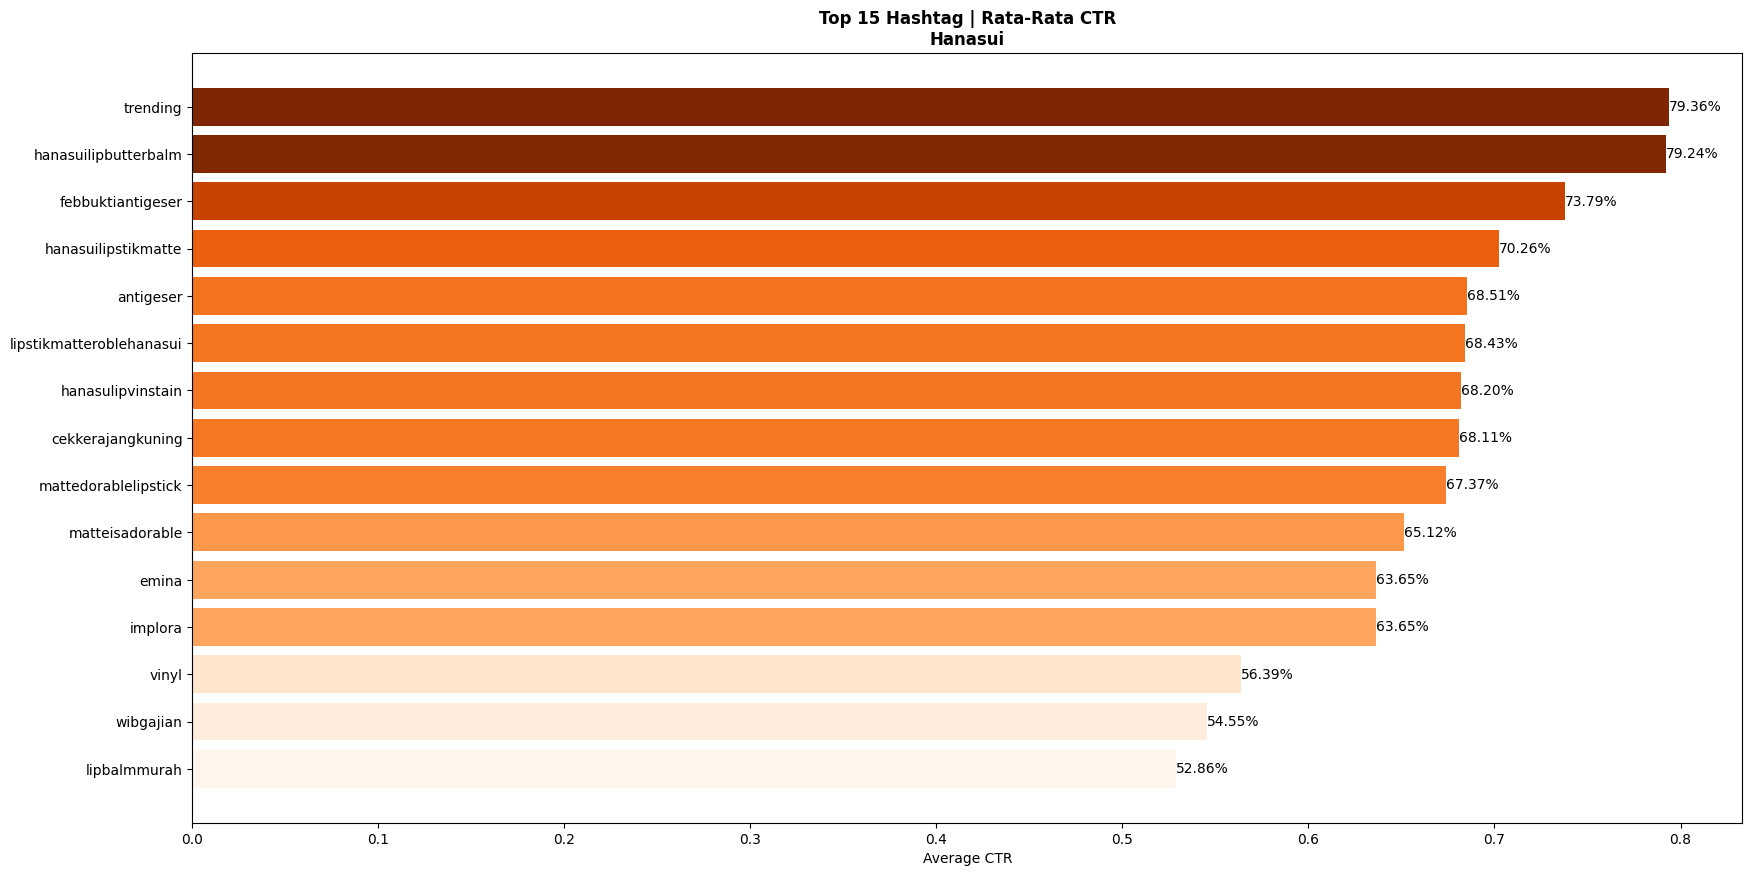

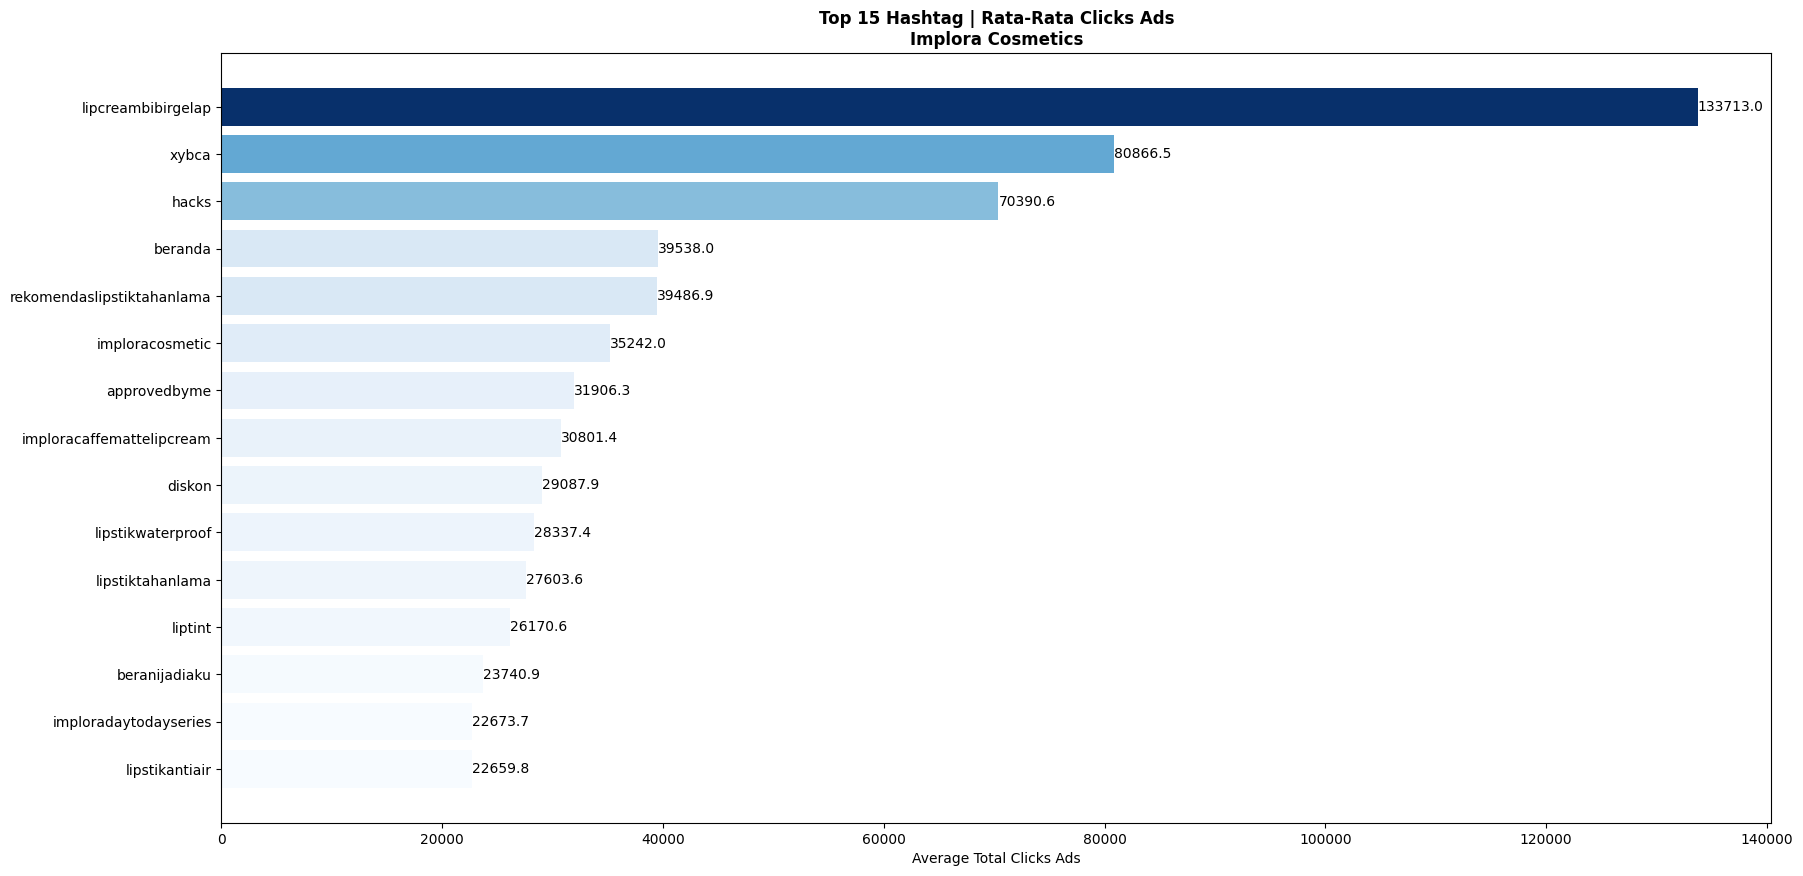

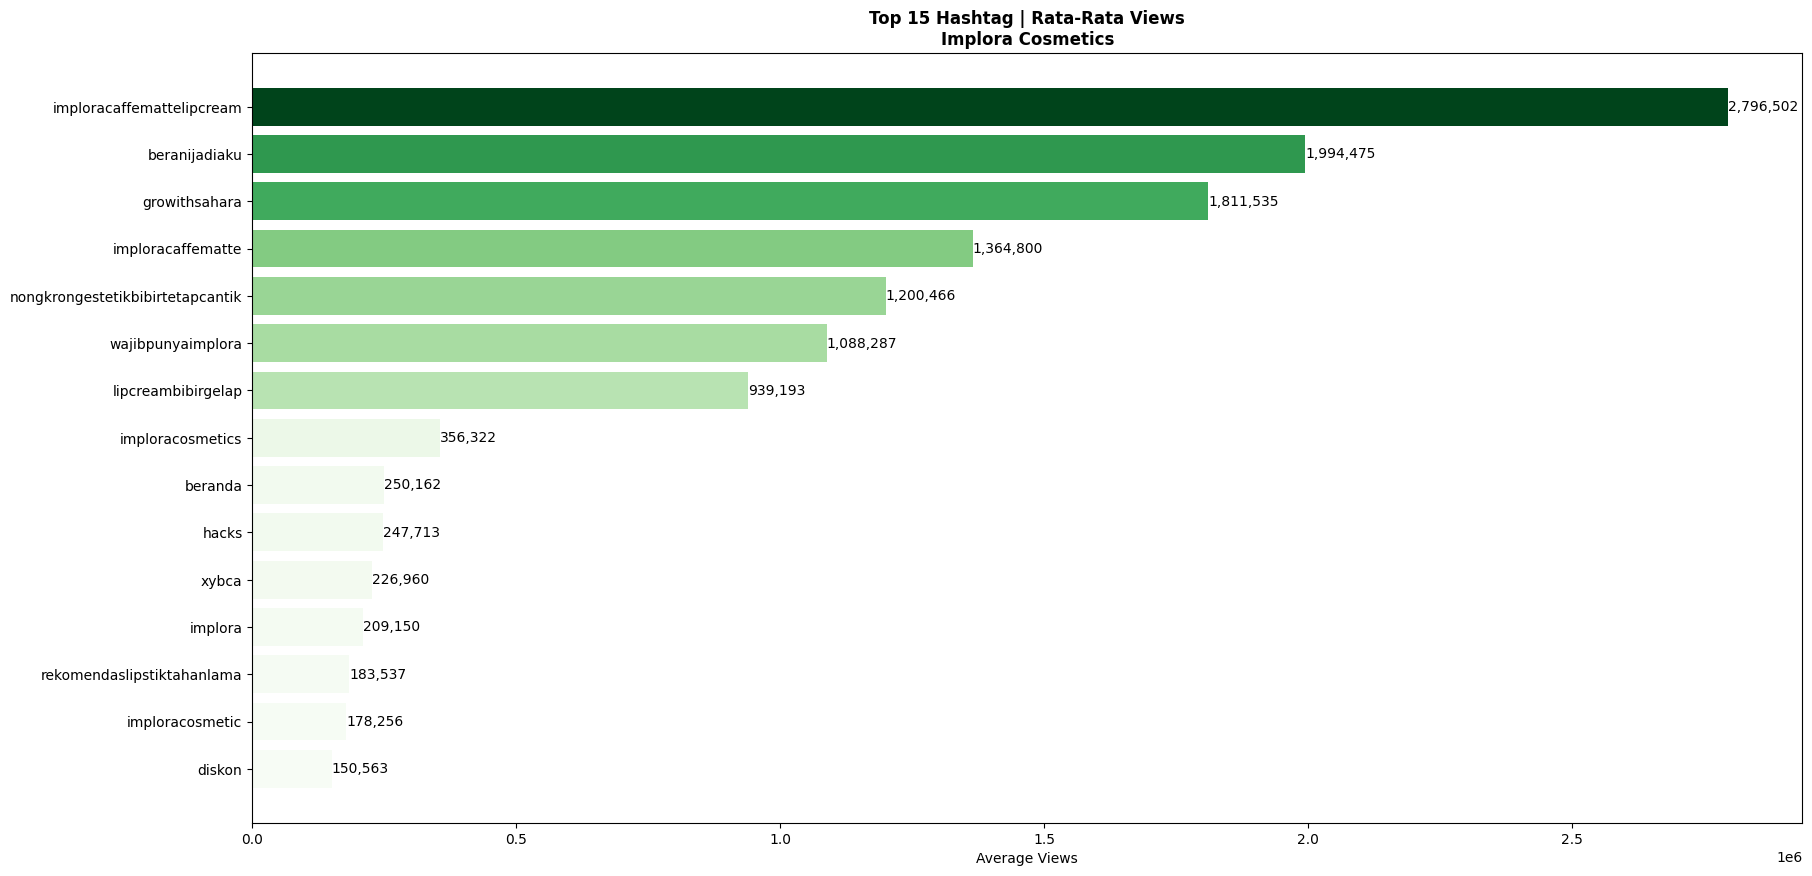

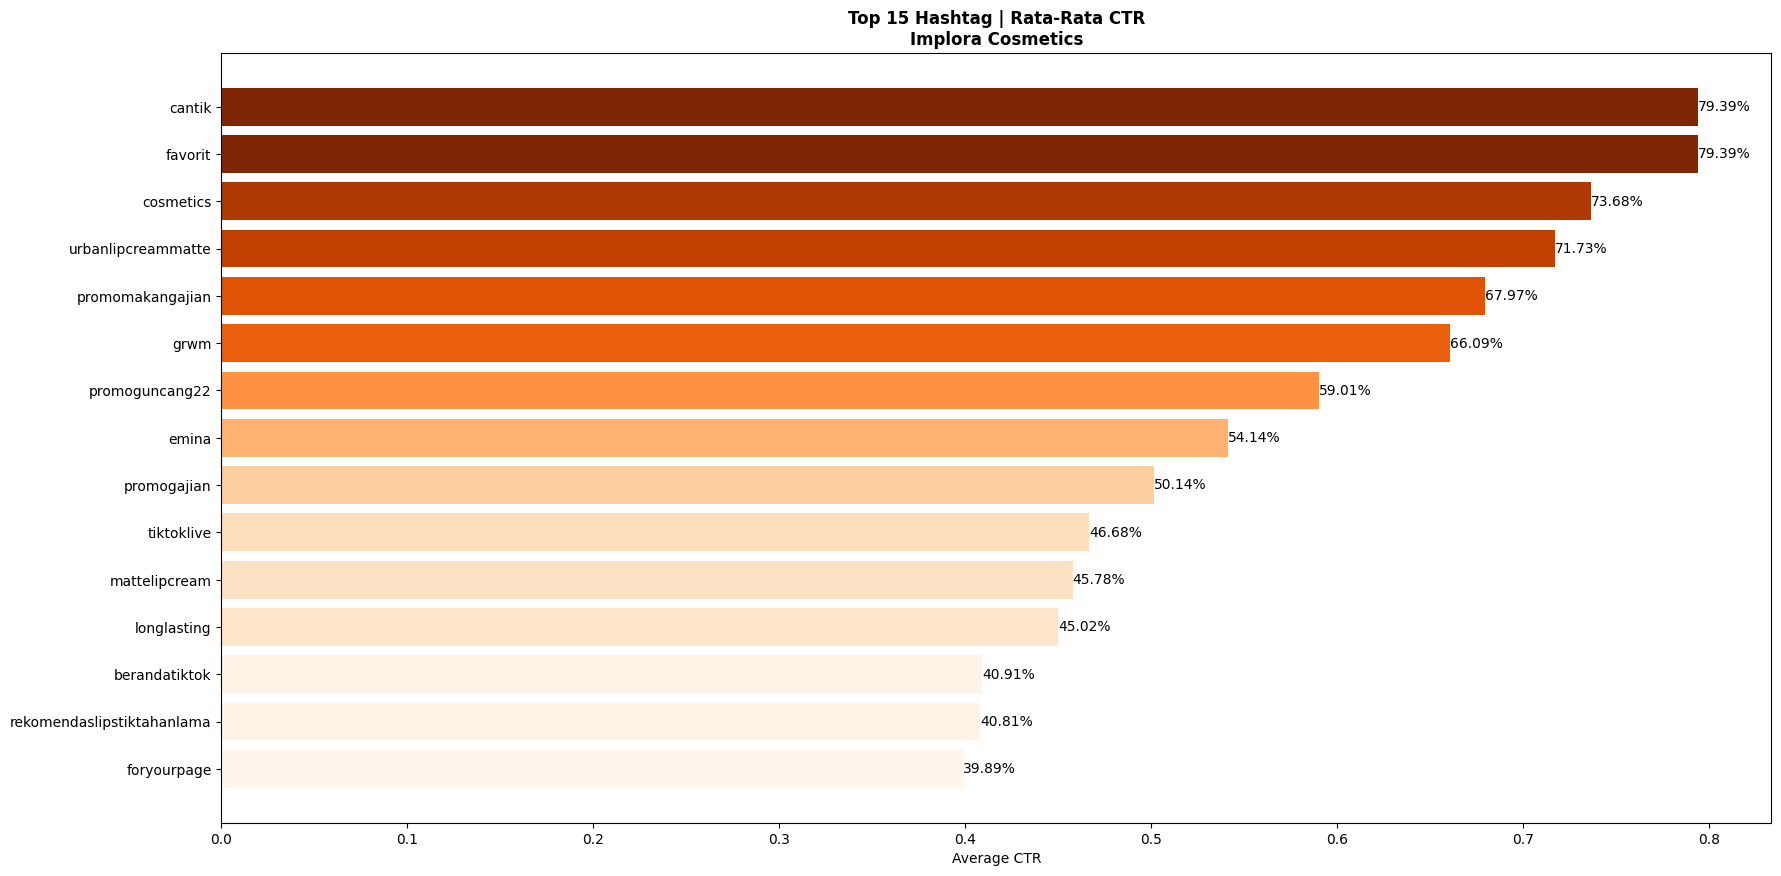

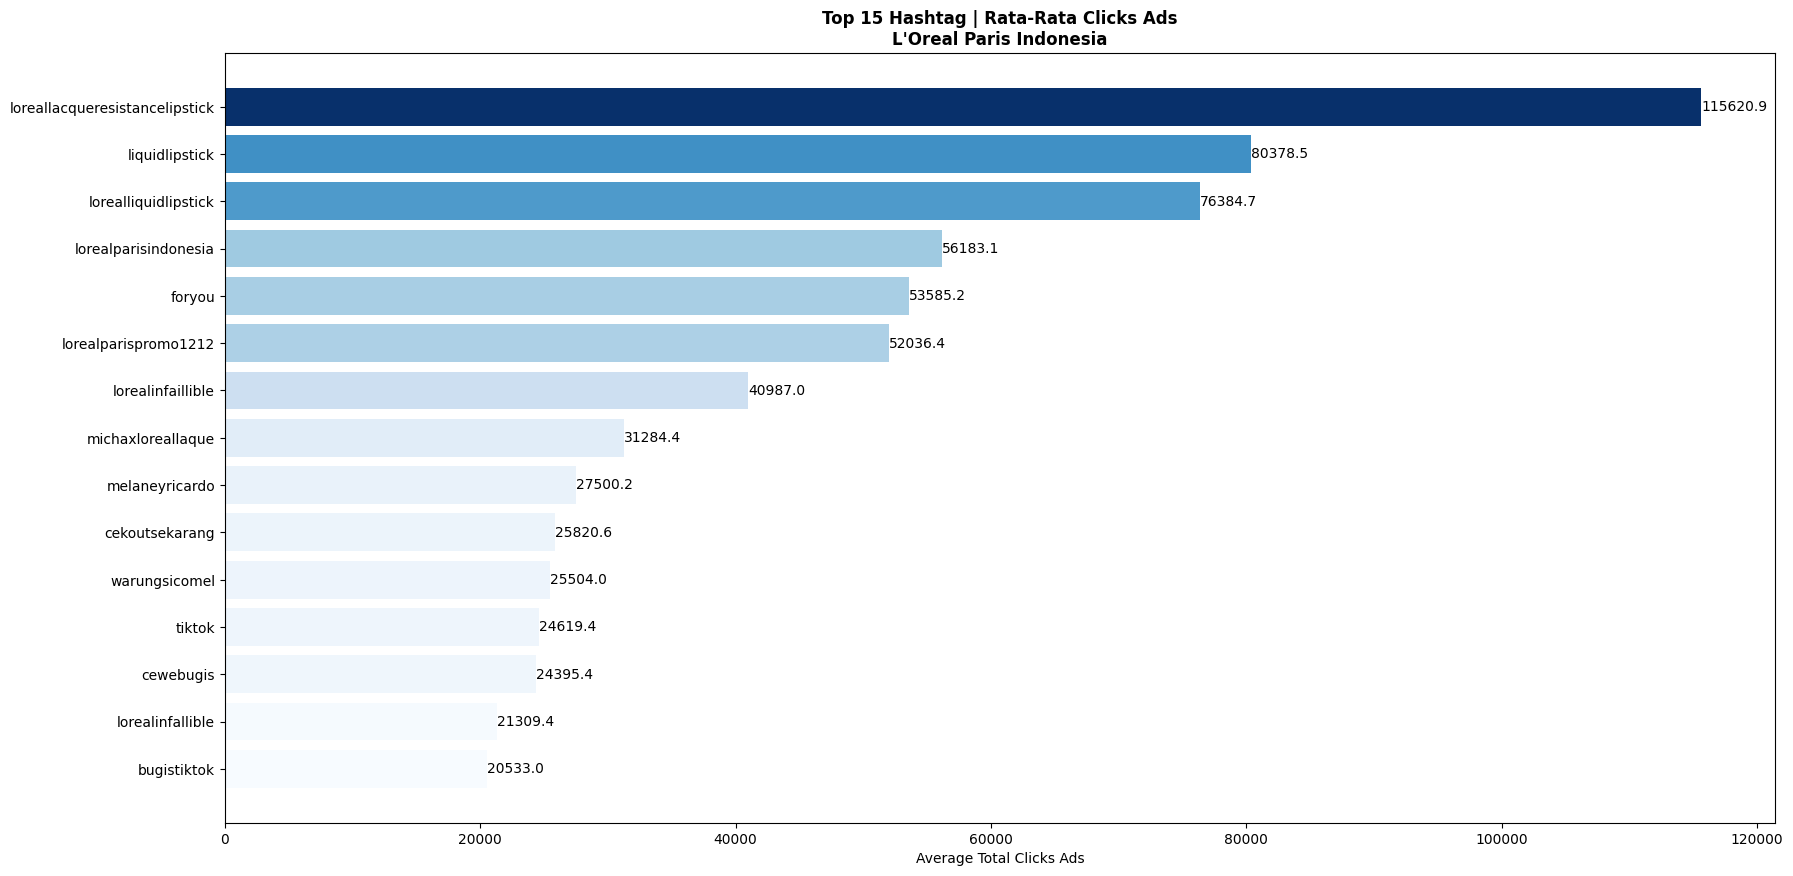

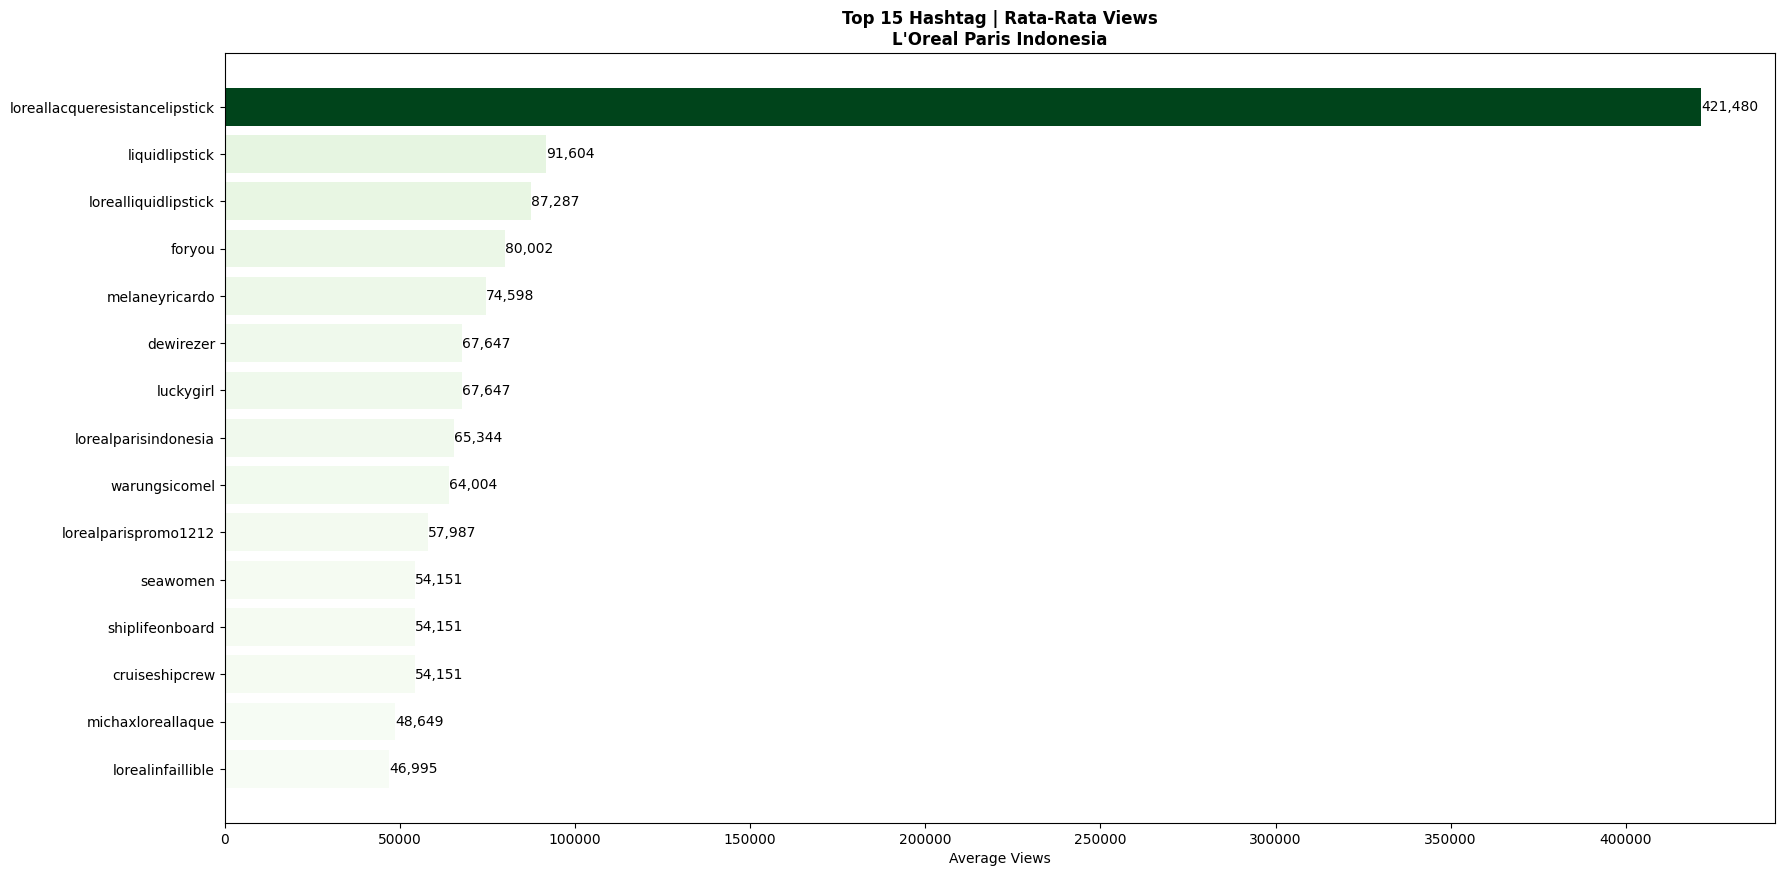

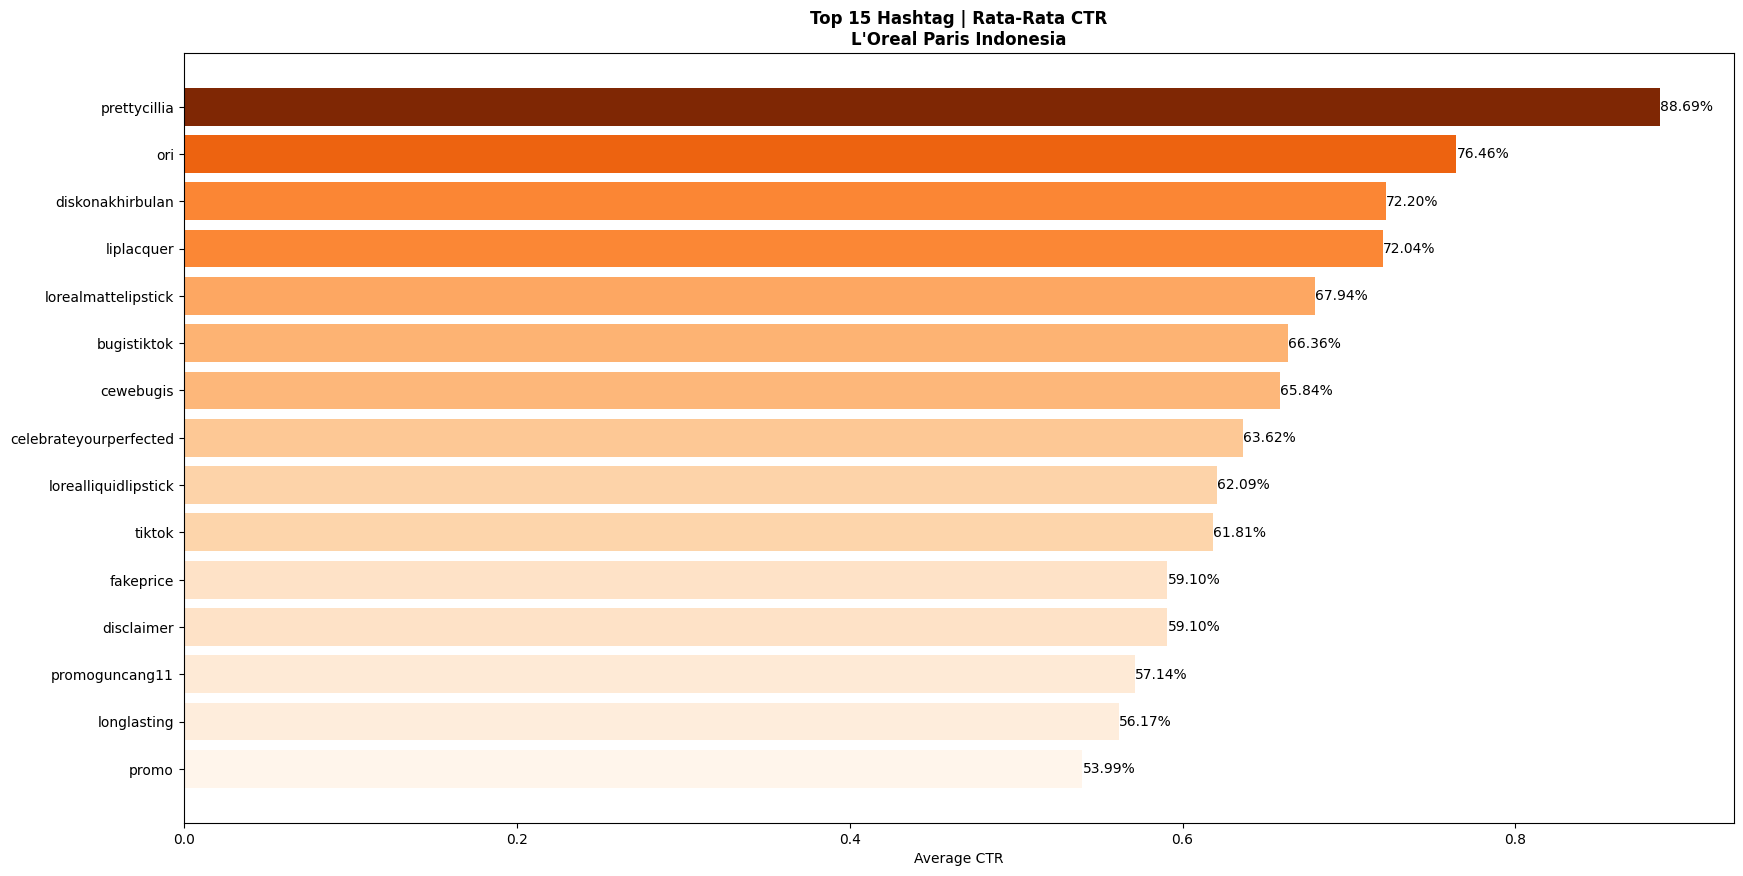

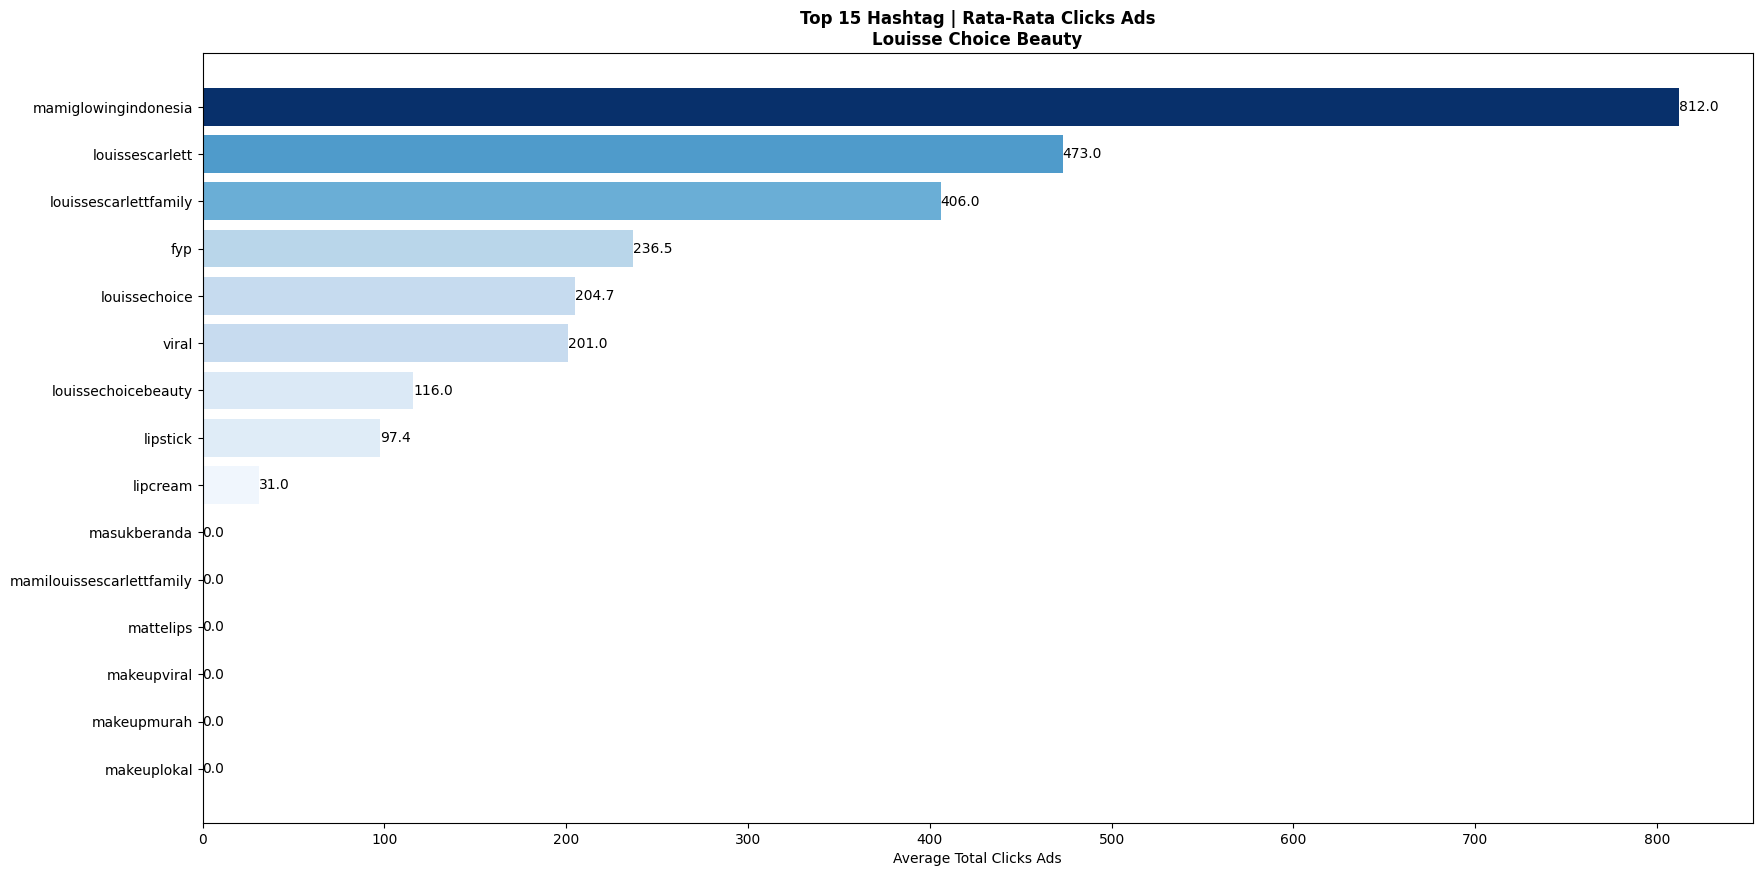

C:\Users\febyrenaldi\AppData\Roaming\Python\Python311-arm64\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12471 (\N{KATAKANA LETTER SI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


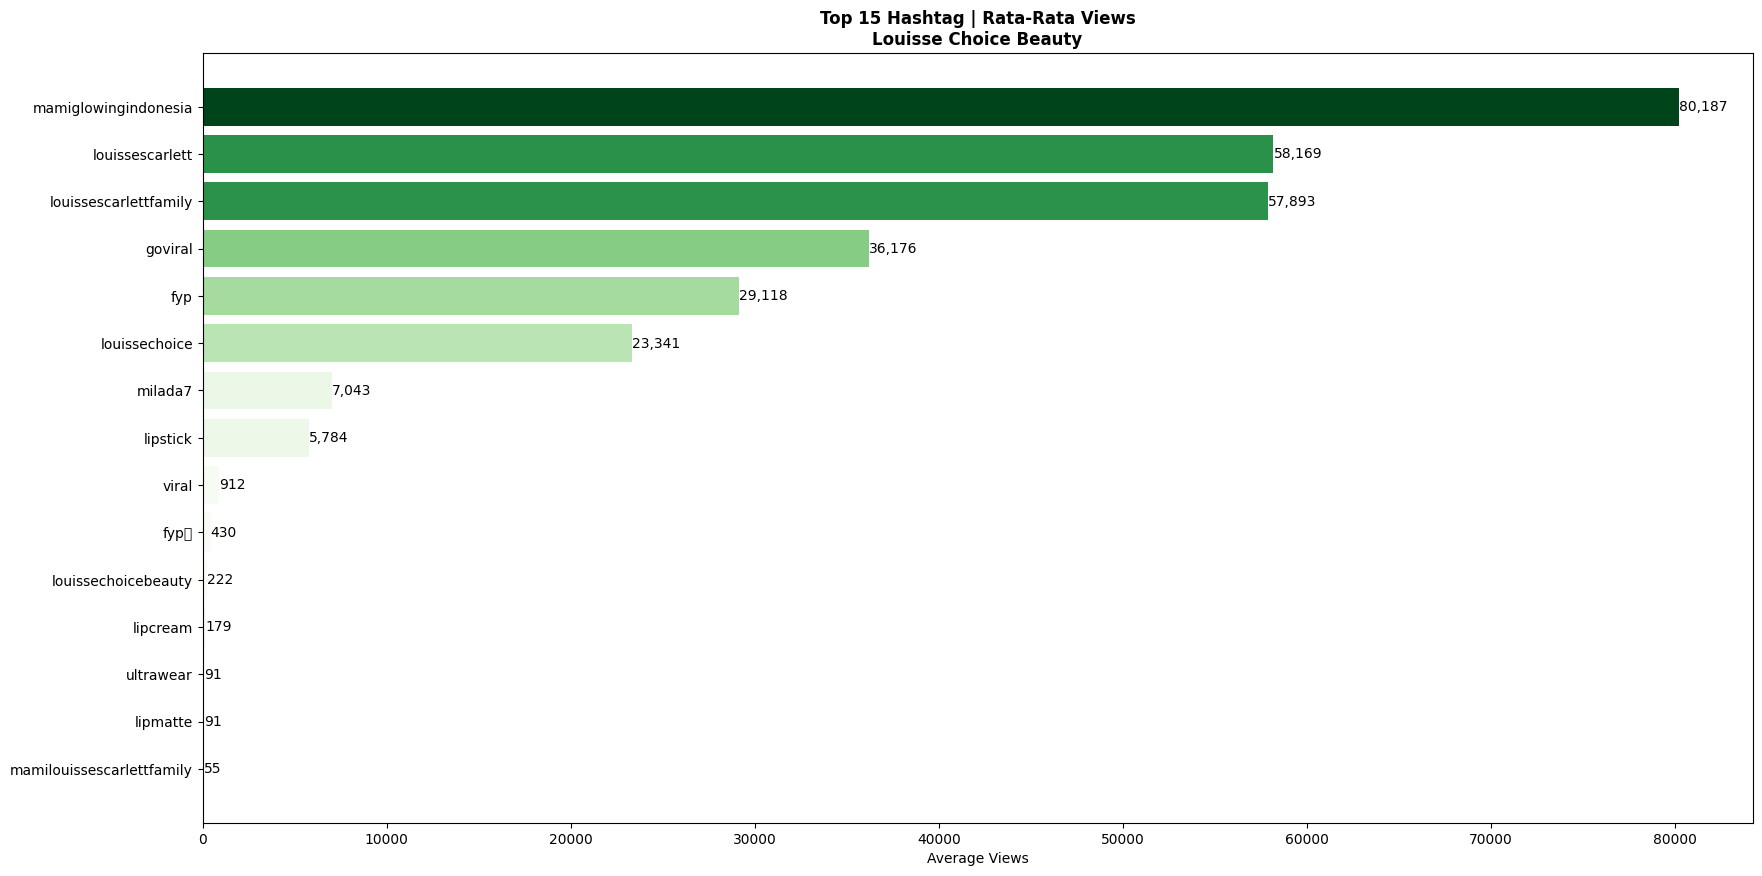

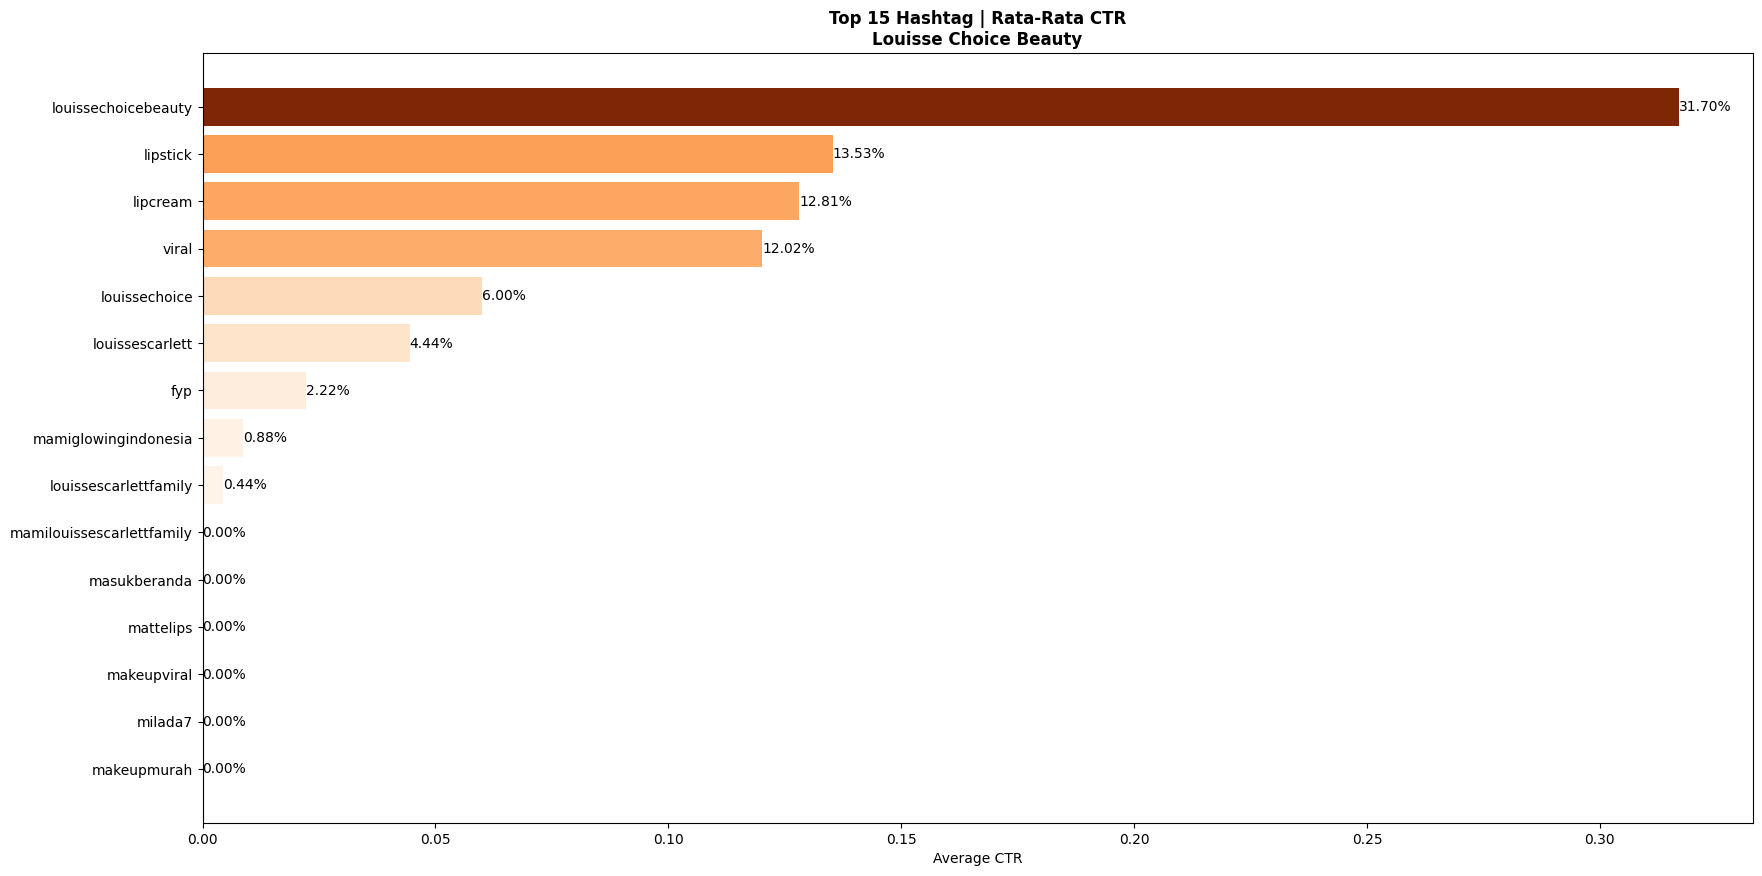

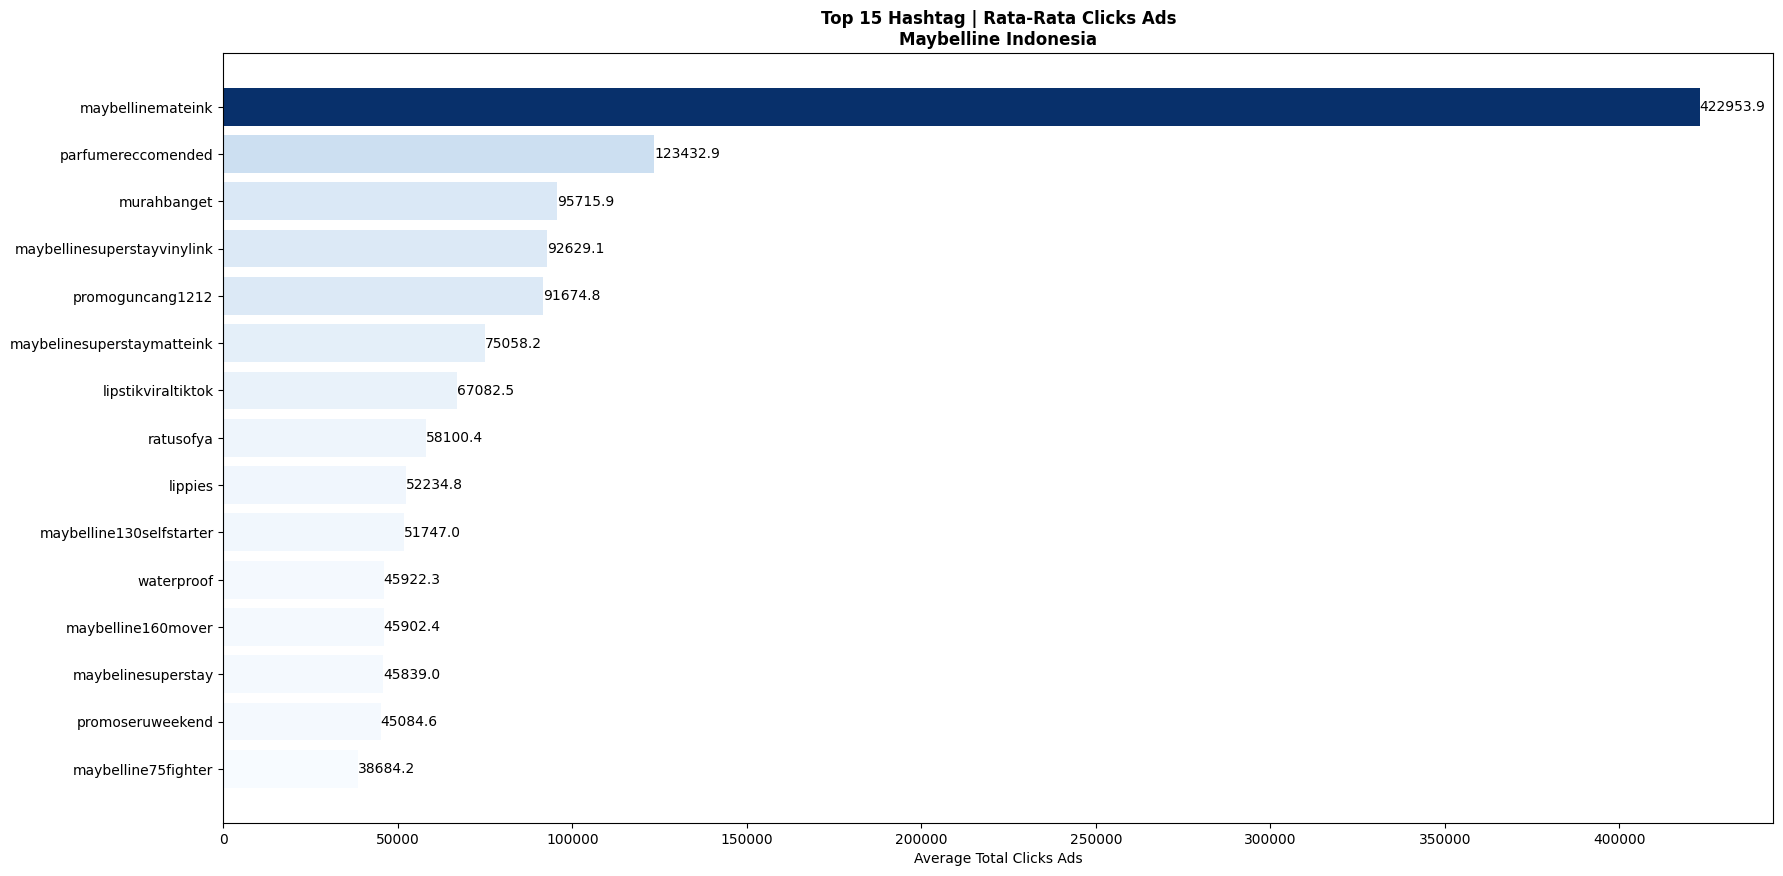

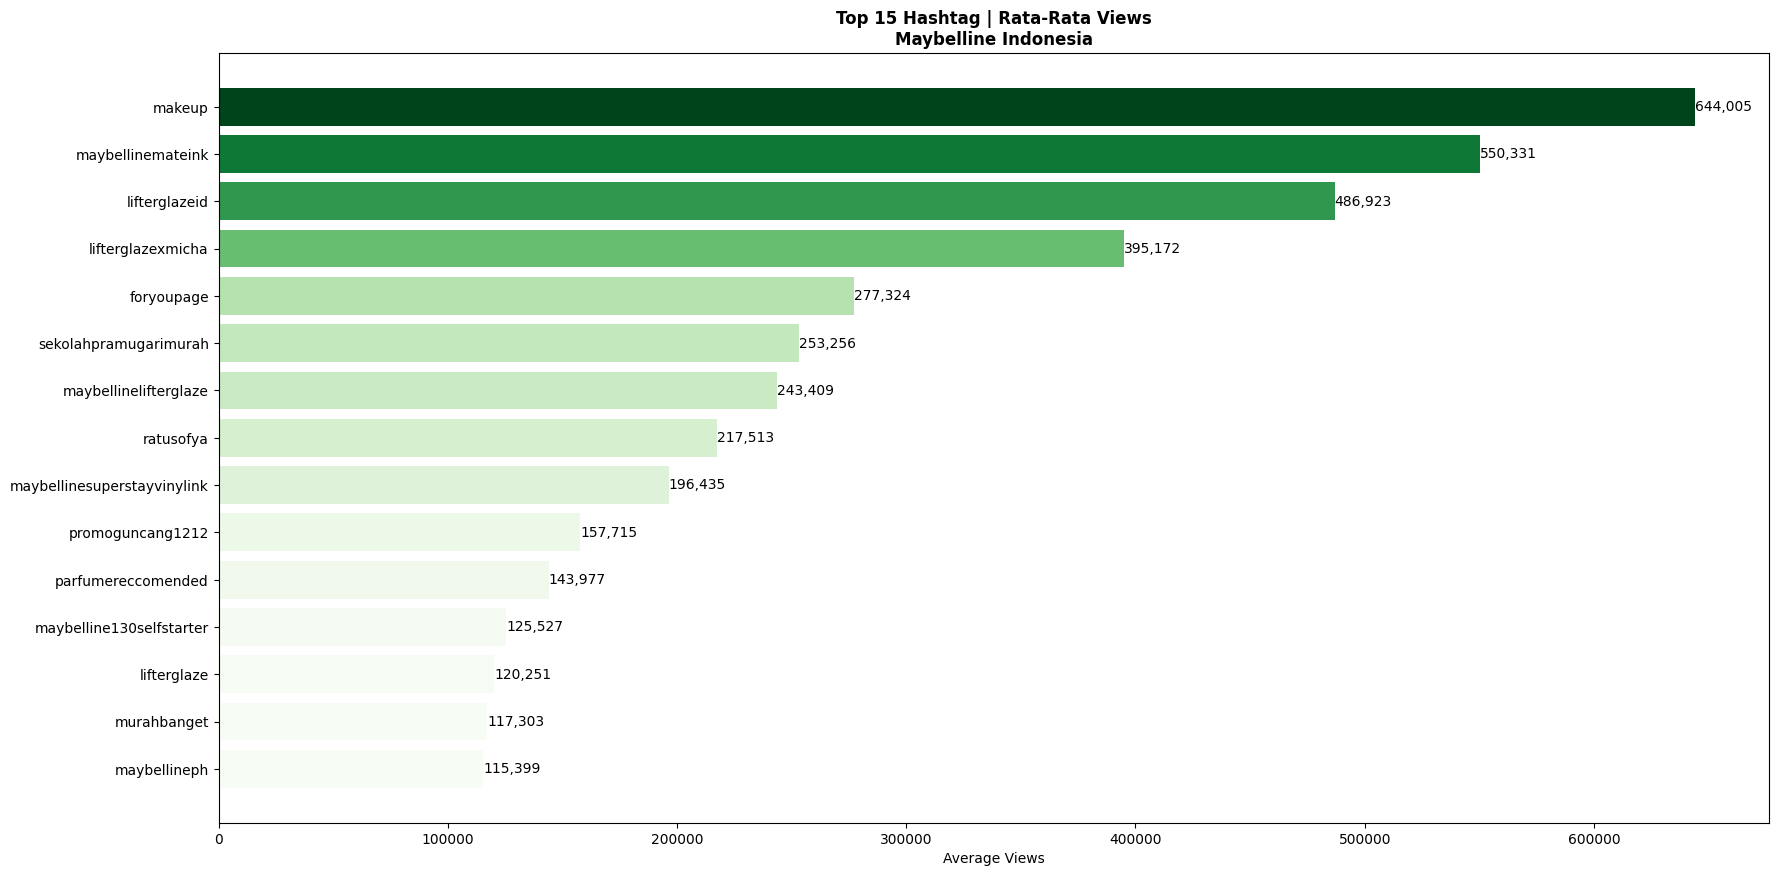

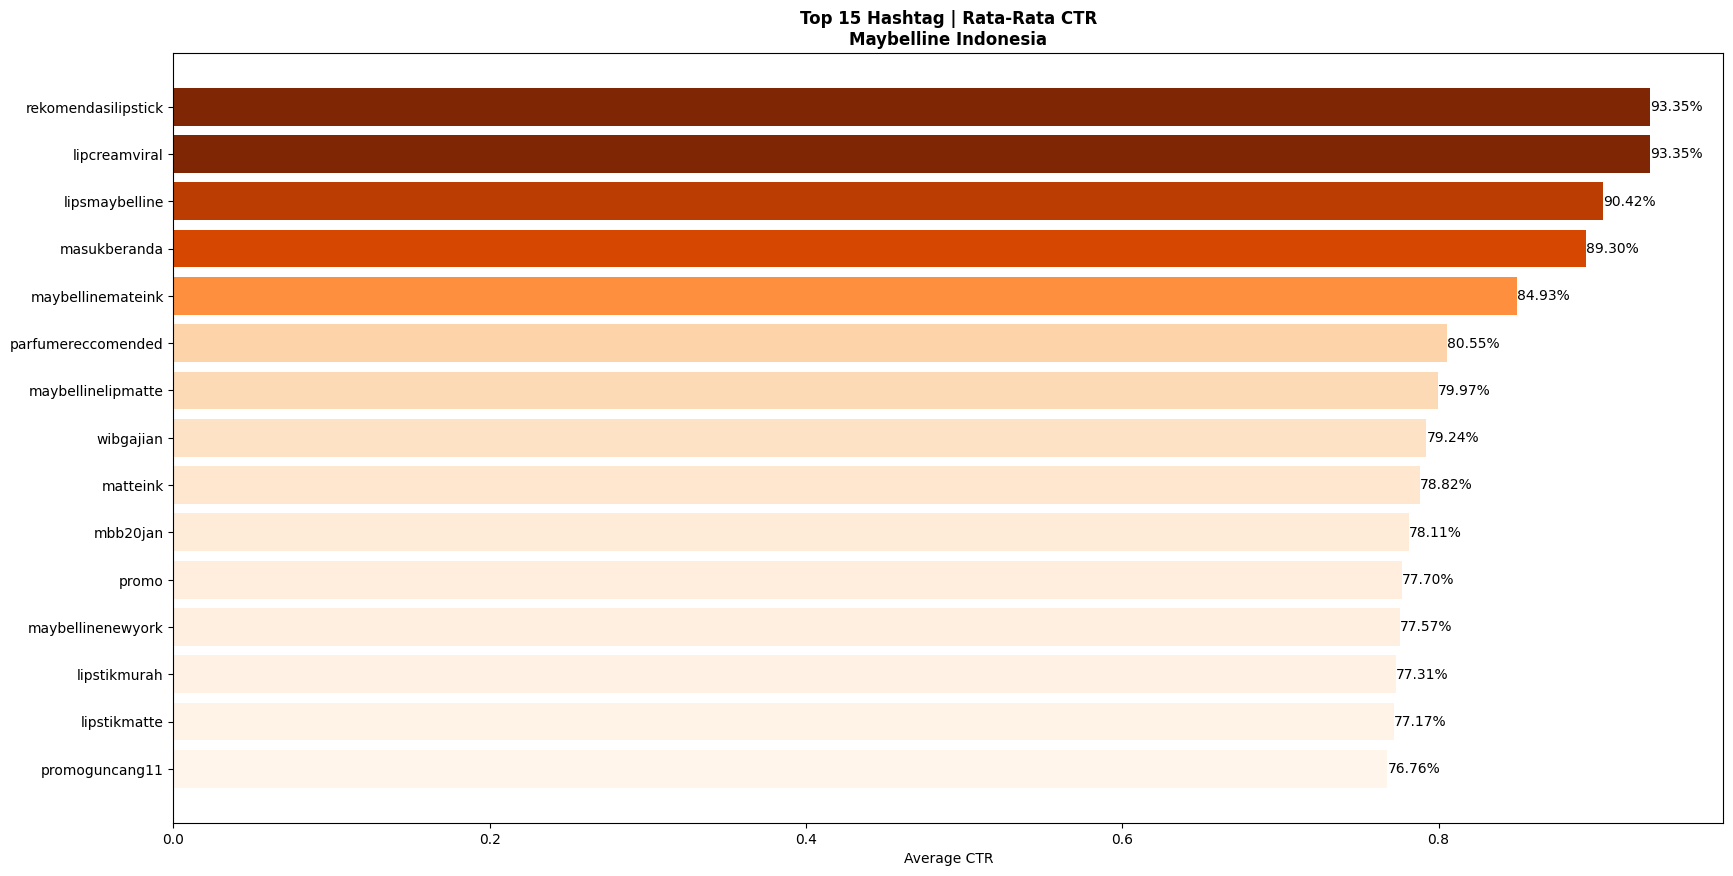

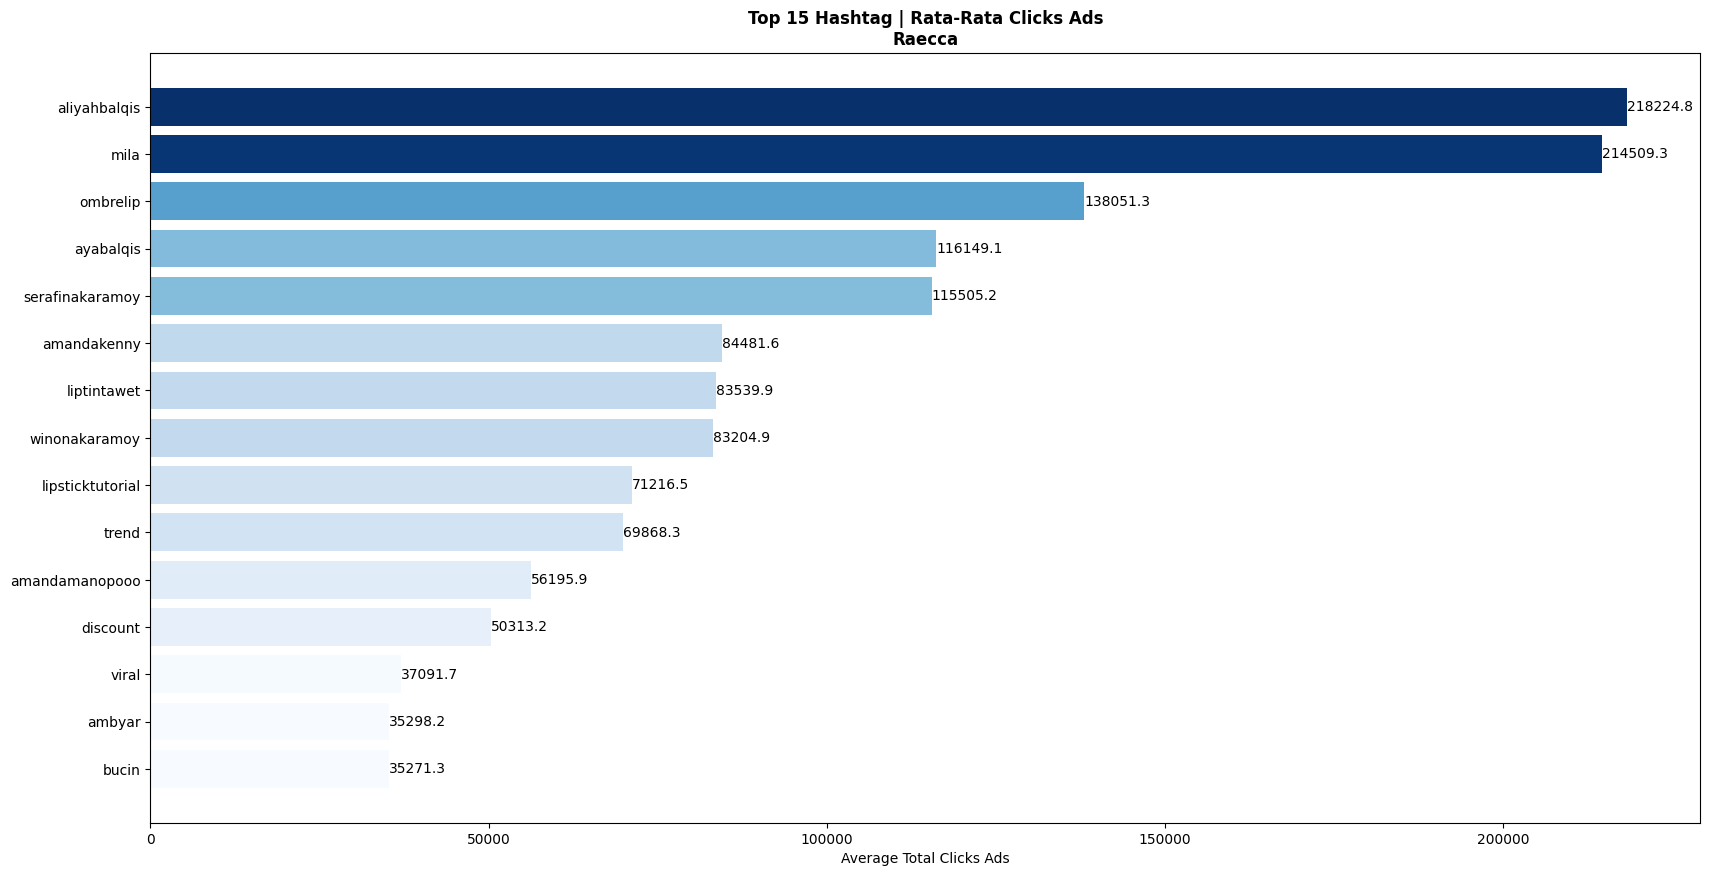

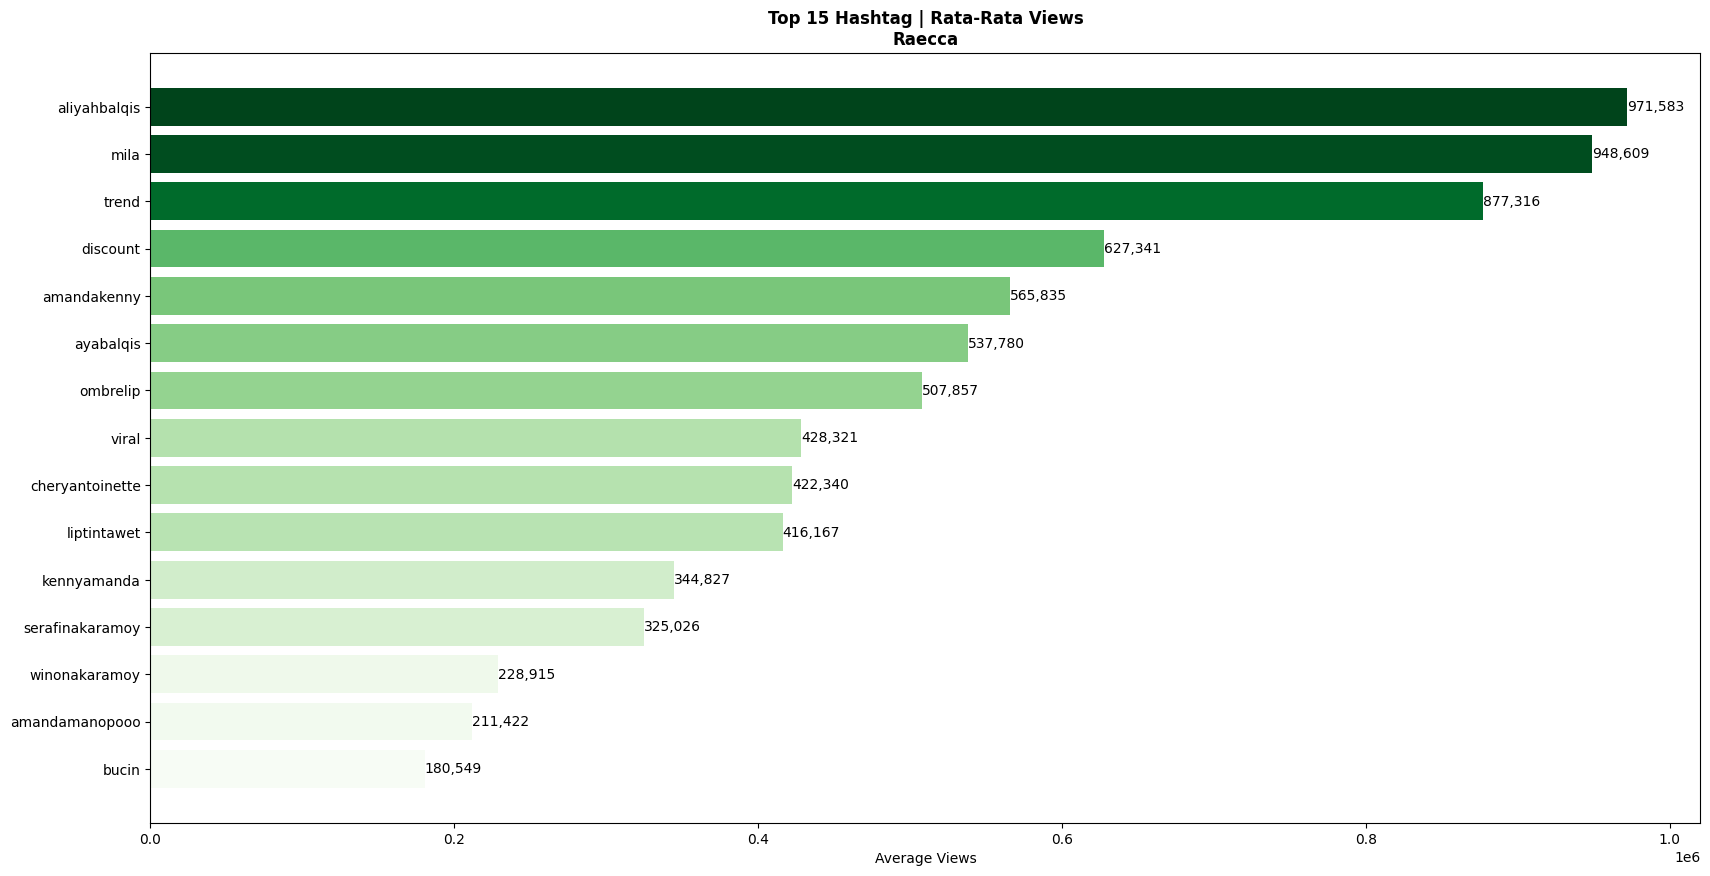

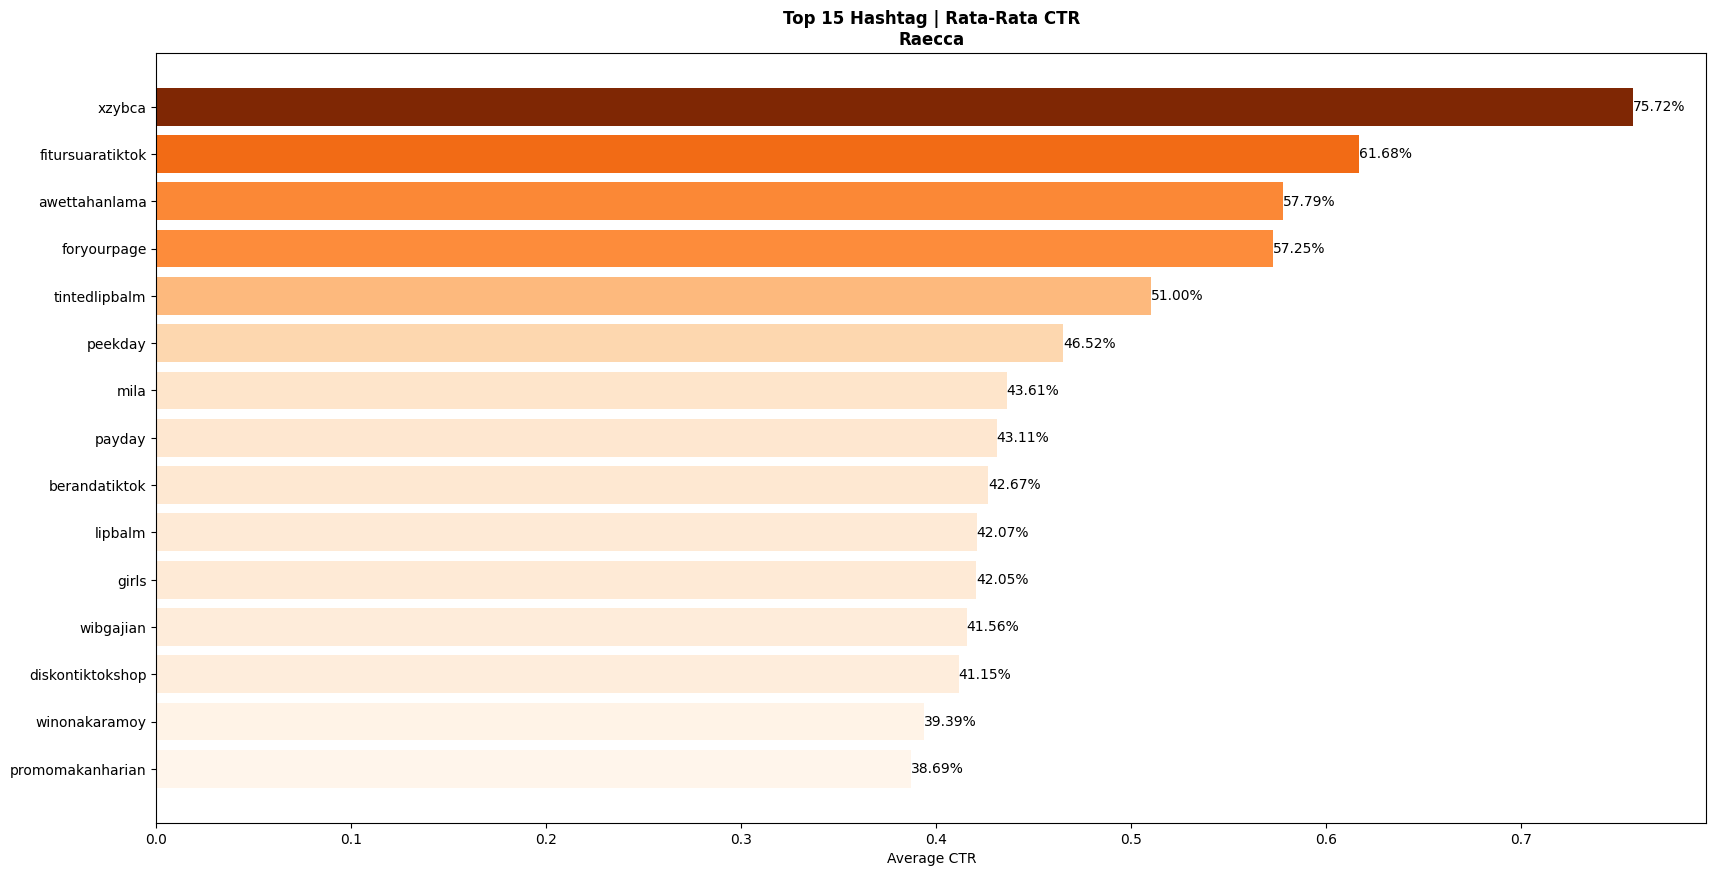

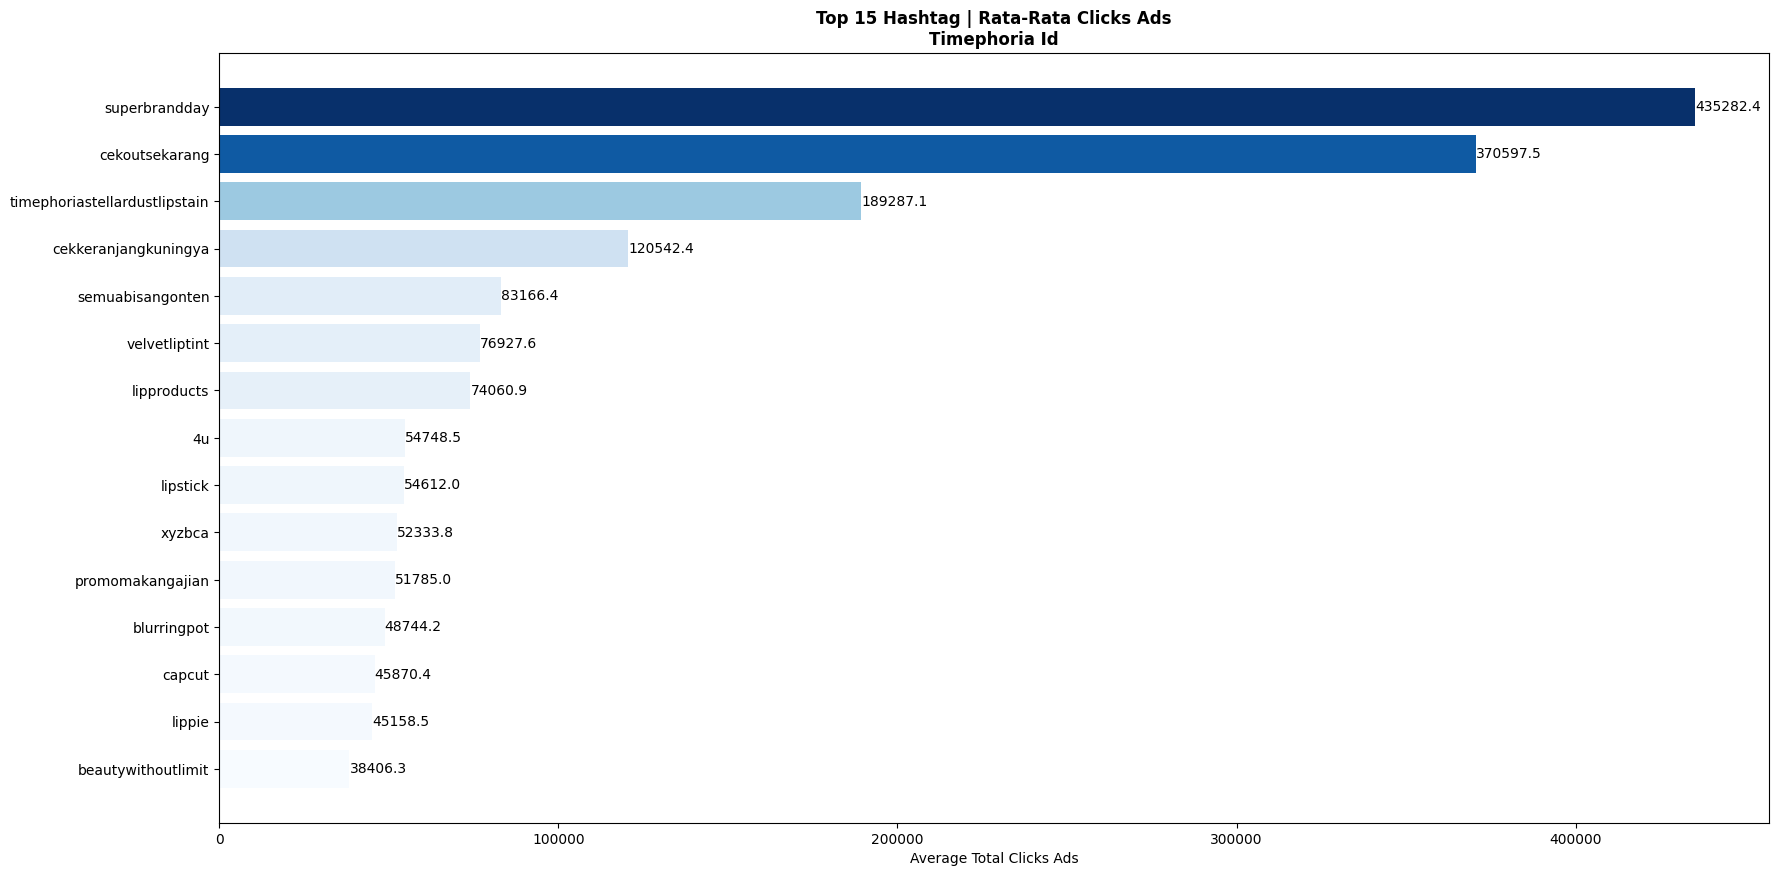

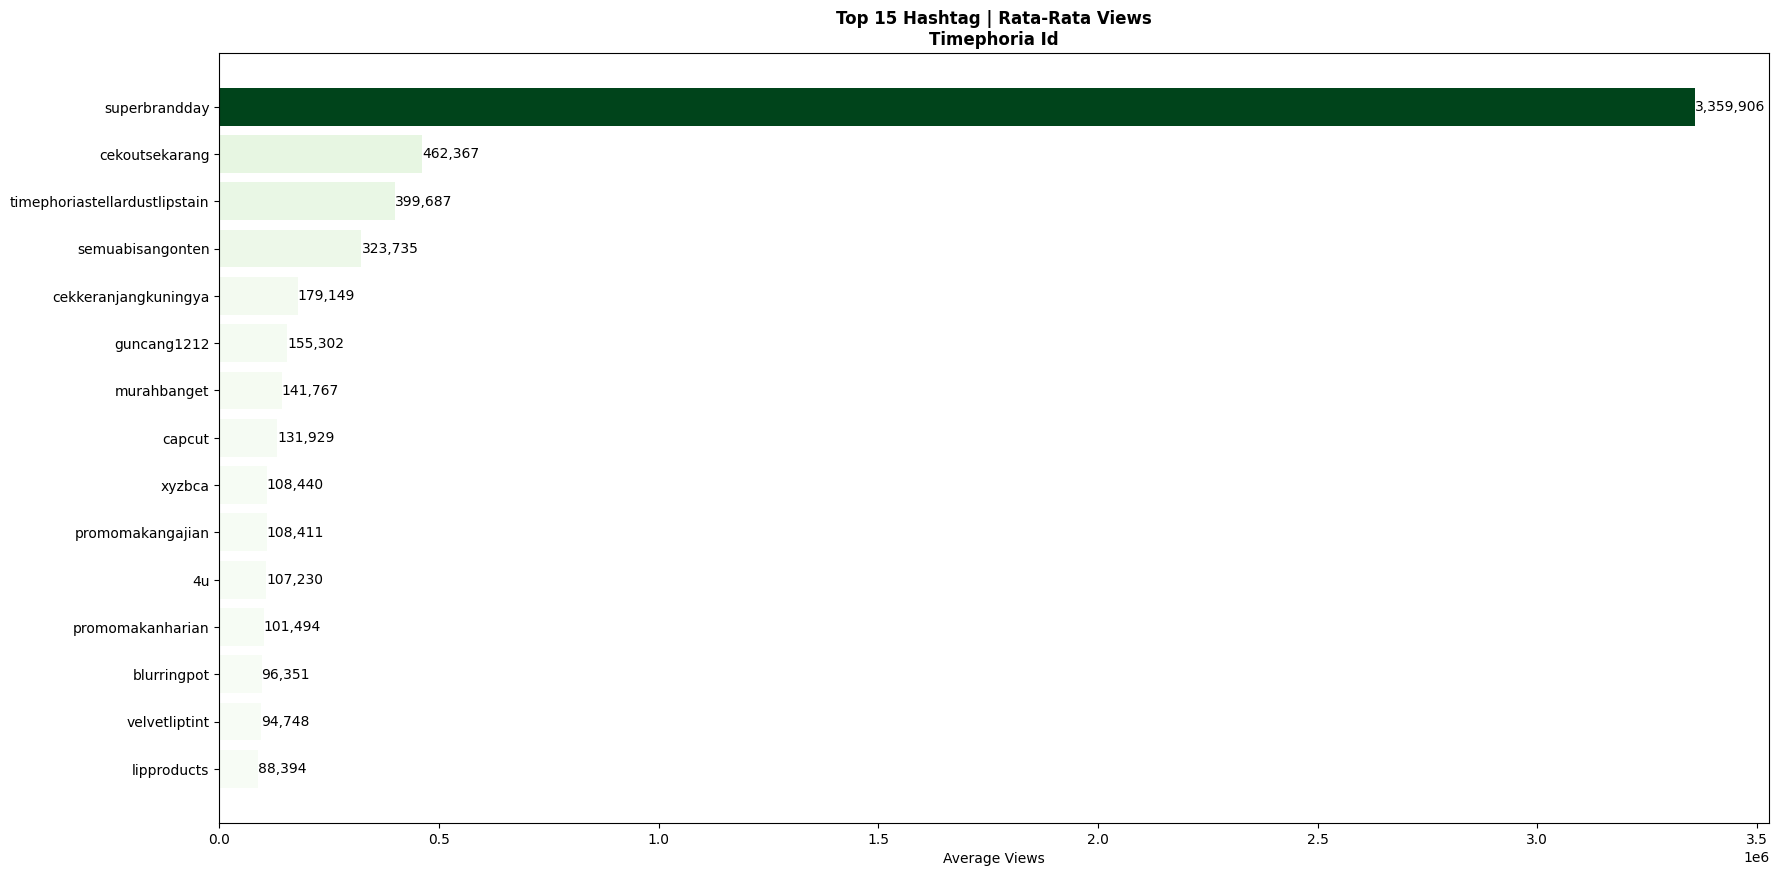

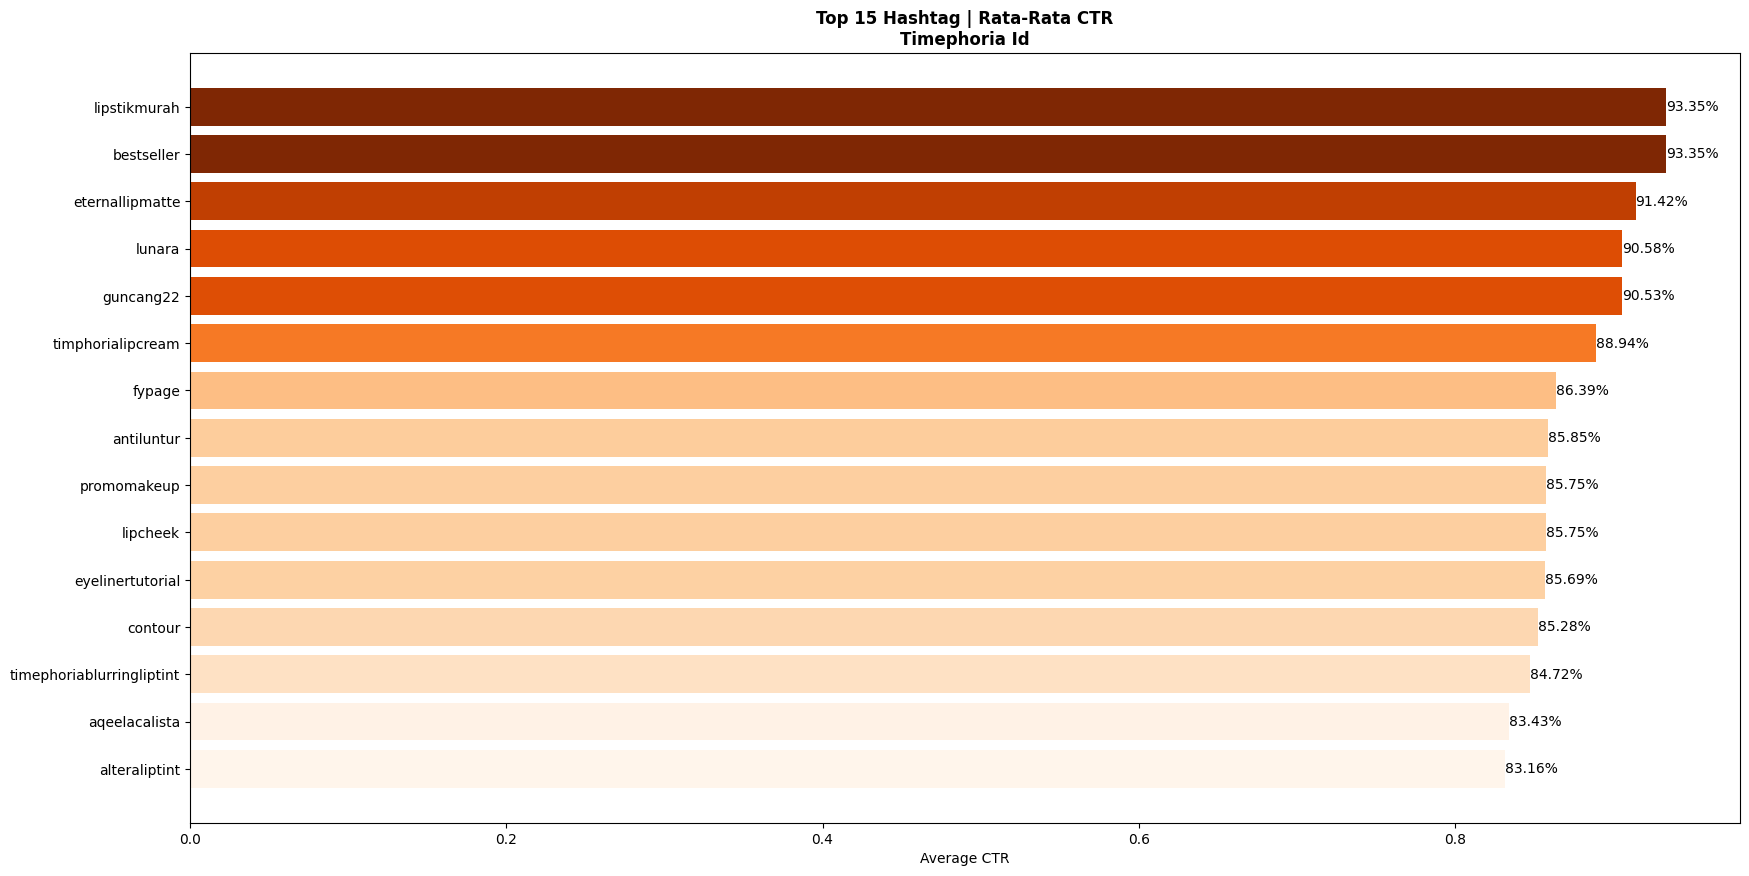

In [7]:
brands = agg_df['Brand'].unique()

for brand in brands:
    brand_df = agg_df[agg_df['Brand'] == brand]

    # =================================================
    # 1. AVG TOTAL CLICKS ADS (GRADASI BIRU)
    # =================================================
    top_clicks = brand_df.sort_values('avg_clicks_ads', ascending=False).head(15)

    norm = Normalize(top_clicks['avg_clicks_ads'].min(),
                     top_clicks['avg_clicks_ads'].max())
    colors = cm.Blues(norm(top_clicks['avg_clicks_ads']))

    plt.figure(figsize=(20,10))
    bars = plt.barh(
        top_clicks['hashtag'],
        top_clicks['avg_clicks_ads'],
        color=colors
    )

    plt.xlabel('Average Total Clicks Ads')
    plt.title(f'Top 15 Hashtag | Rata-Rata Clicks Ads\n{brand}')
    plt.gca().invert_yaxis()

    for bar in bars:
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.1f}",
            va='center',
            ha='left'
        )

    plt.show()

    # =================================================
    # 2. AVG VIEWS (GRADASI HIJAU)
    # =================================================
    top_views = brand_df.sort_values('avg_views', ascending=False).head(15)

    norm = Normalize(top_views['avg_views'].min(),
                     top_views['avg_views'].max())
    colors = cm.Greens(norm(top_views['avg_views']))

    plt.figure(figsize=(20,10))
    bars = plt.barh(
        top_views['hashtag'],
        top_views['avg_views'],
        color=colors
    )

    plt.xlabel('Average Views')
    plt.title(f'Top 15 Hashtag | Rata-Rata Views\n{brand}')
    plt.gca().invert_yaxis()

    for bar in bars:
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height()/2,
            f"{int(bar.get_width()):,}",
            va='center',
            ha='left'
        )

    plt.show()

    # =================================================
    # 3. AVG CTR (GRADASI ORANYE)
    # =================================================
    top_ctr = brand_df.sort_values('avg_ctr', ascending=False).head(15)

    norm = Normalize(top_ctr['avg_ctr'].min(),
                     top_ctr['avg_ctr'].max())
    colors = cm.Oranges(norm(top_ctr['avg_ctr']))

    plt.figure(figsize=(20,10))
    bars = plt.barh(
        top_ctr['hashtag'],
        top_ctr['avg_ctr'],
        color=colors
    )

    plt.xlabel('Average CTR')
    plt.title(f'Top 15 Hashtag | Rata-Rata CTR\n{brand}')
    plt.gca().invert_yaxis()

    for bar in bars:
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.2%}",
            va='center',
            ha='left'
        )

    plt.show()